# Topology Ablation: Does Graph Structure Matter?

It assumes the encode → Koopman step → decode workflow from [`01_synthetic_graph.ipynb`](01_synthetic_graph.ipynb). Here we run two matched ablations: **topology** on path-diffusion trajectories, then an **encoder zoo** on directional advection.

KoopmanGraph is **topology-aware**: the encoder and decoder pass messages along edges.
This notebook asks a practical question: *what happens if we train on the right node
trajectories but the wrong graph?*

We generate dynamics on a **path graph**, then train three models that see identical
node features but different `edge_index` choices:

1. **Correct** — true path topology used to generate the data
2. **Shuffled** — same edge count, random destination rewiring
3. **Ring** — periodic ring topology (wrong boundary conditions for path diffusion)

Each model is evaluated with the topology it was trained on.
A later section compares GCN / SAGE / DiffConv / Transformer on anisotropic advection.


## Method: topology and encoder ablations

Train matched models on true path, shuffled, and ring-mismatch graphs, then
compare rollout error. A second experiment sweeps encoder architectures
(GCN / SAGE / DiffConv / Transformer) on directional advection.


In [1]:
import warnings

from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

import os

import matplotlib

if os.environ.get("PYTEST_CURRENT_TEST"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import torch
from torch_geometric.data import Data

try:
    from IPython import get_ipython

    if get_ipython() is not None and not os.environ.get("PYTEST_CURRENT_TEST"):
        get_ipython().run_line_magic("matplotlib", "inline")
except (ImportError, NameError):
    pass

from koopman_graph import (
    DiffConvDecoder,
    DiffConvEncoder,
    GNNDecoder,
    GNNEncoder,
    GraphKoopmanModel,
    GraphSnapshotSequence,
    GraphTransformerDecoder,
    GraphTransformerEncoder,
    SAGEDecoder,
    SAGEEncoder,
)
from koopman_graph.training import LossWeights
from koopman_graph.datasets import (
    AnisotropicAdvectionGridBenchmark,
    SyntheticDynamicGraphBenchmark,
)

IS_CI = bool(os.environ.get("PYTEST_CURRENT_TEST"))

# Topology ablation (path diffusion)
NUM_NODES = 20
NUM_TIMESTEPS = 20 if IS_CI else 35
IN_CHANNELS = 2
DATA_SEED = 7
DECAY_RATE = 0.96
DIFFUSION_RATE = 0.35
NOISE_STD = 0.01
SHUFFLE_EDGE_SEED = 123

HIDDEN = 48
LATENT = 48
EPOCHS = 30 if IS_CI else 100
MODEL_SEED = 0
PREDICT_STEPS = 10
TIME_STEP = 0.1
LR = 1e-3
TOPOLOGY_LOSS_WEIGHTS = LossWeights(
    reconstruction=1.0, forward=0.5, rollout=0.5
)

# Encoder zoo (anisotropic advection)
ADV_ROWS = 4 if IS_CI else 8
ADV_COLS = 4 if IS_CI else 8
ADV_TIMESTEPS = 12 if IS_CI else 30
ADV_SEED = 0
ADV_IN = 3  # AnisotropicAdvectionGridBenchmark default in_channels
ADV_HIDDEN = 16 if IS_CI else 32
ADV_LATENT = 16 if IS_CI else 32
ADV_EPOCHS = 3 if IS_CI else 40
ADV_STEPS = 3 if IS_CI else 5
ADV_LOSS_WEIGHTS = LossWeights(reconstruction=1.0, forward=1.0, rollout=2.0)

# Path-diffusion data (used by topology ablation helpers below)
data_sequence = SyntheticDynamicGraphBenchmark.generate(
    num_nodes=NUM_NODES,
    num_timesteps=NUM_TIMESTEPS,
    in_channels=IN_CHANNELS,
    topology="path",
    seed=DATA_SEED,
    initial_state="random",
    decay_rate=DECAY_RATE,
    diffusion_rate=DIFFUSION_RATE,
    noise_std=NOISE_STD,
)
correct_edge_index = data_sequence.edge_index
assert data_sequence.num_nodes == NUM_NODES
assert data_sequence.in_channels == IN_CHANNELS


## Helper functions

Notebook-local helpers used below.


In [2]:
def ring_edge_index(num_nodes: int) -> torch.Tensor:
    src: list[int] = []
    dst: list[int] = []
    for node in range(num_nodes):
        nxt = (node + 1) % num_nodes
        src.extend([node, nxt])
        dst.extend([nxt, node])
    return torch.tensor([src, dst], dtype=torch.long)

def shuffle_edge_index(edge_index: torch.Tensor, *, seed: int) -> torch.Tensor:
    generator = torch.Generator().manual_seed(seed)
    perm = torch.randperm(edge_index.shape[1], generator=generator)
    shuffled = edge_index.clone()
    shuffled[1] = edge_index[1][perm]
    return shuffled

def with_edge_index(edge_index: torch.Tensor, sequence: GraphSnapshotSequence) -> GraphSnapshotSequence:
    snapshots = [
        Data(x=snapshot.x.clone(), edge_index=edge_index)
        for snapshot in sequence
    ]
    return GraphSnapshotSequence(snapshots)

def build_model() -> GraphKoopmanModel:
    encoder = GNNEncoder(IN_CHANNELS, HIDDEN, LATENT)
    decoder = GNNDecoder(LATENT, HIDDEN, IN_CHANNELS)
    return GraphKoopmanModel(
        encoder=encoder,
        decoder=decoder,
        latent_dim=LATENT,
        time_step=TIME_STEP,
    )

def train_on_topology(name: str, edge_index: torch.Tensor) -> GraphKoopmanModel:
    sequence = with_edge_index(edge_index, data_sequence)
    torch.manual_seed(MODEL_SEED)
    model = build_model()
    model.fit(
        sequence,
        epochs=EPOCHS,
        lr=LR,
        loss_weights=TOPOLOGY_LOSS_WEIGHTS,
        rollout_horizon=PREDICT_STEPS,
    )
    print(f"Trained: {name}")
    return model

def rollout_mse(model: GraphKoopmanModel, edge_index: torch.Tensor, steps: int) -> float:
    initial = Data(x=data_sequence[0].x.clone(), edge_index=edge_index)
    model.eval()
    with torch.no_grad():
        preds = model.predict(initial, steps=steps)
    truth = data_sequence[1 : 1 + steps]
    per_step = [torch.mean((p.x - t.x) ** 2) for p, t in zip(preds, truth, strict=True)]
    return torch.stack(per_step).mean().item()

def _rollout_mse_on_sequence(model: GraphKoopmanModel, sequence, steps: int) -> float:
    preds = model.predict(sequence[0], steps=steps)
    truth = sequence[1 : steps + 1]
    return float(
        torch.mean(
            torch.stack(
                [
                    torch.mean((pred.x - snap.x) ** 2)
                    for pred, snap in zip(preds, truth, strict=True)
                ]
            )
        ).item()
    )

def build_encoder_zoo_model(kind: str) -> GraphKoopmanModel:
    if kind == "GCN":
        encoder = GNNEncoder(ADV_IN, ADV_HIDDEN, ADV_LATENT)
        decoder = GNNDecoder(ADV_LATENT, ADV_HIDDEN, ADV_IN)
    elif kind == "SAGE":
        encoder = SAGEEncoder(ADV_IN, ADV_HIDDEN, ADV_LATENT)
        decoder = SAGEDecoder(ADV_LATENT, ADV_HIDDEN, ADV_IN)
    elif kind == "DiffConv":
        encoder = DiffConvEncoder(ADV_IN, ADV_HIDDEN, ADV_LATENT, diffusion_steps=2)
        decoder = DiffConvDecoder(ADV_LATENT, ADV_HIDDEN, ADV_IN, diffusion_steps=2)
    elif kind == "Transformer":
        encoder = GraphTransformerEncoder(
            ADV_IN, ADV_HIDDEN, ADV_LATENT, heads=2
        )
        decoder = GraphTransformerDecoder(
            ADV_LATENT, ADV_HIDDEN, ADV_IN, heads=2
        )
    else:
        raise ValueError(kind)
    return GraphKoopmanModel(
        encoder=encoder,
        decoder=decoder,
        latent_dim=ADV_LATENT,
        time_step=TIME_STEP,
    )


## Path-diffusion data

`data_sequence` and `correct_edge_index` were built in the setup cell above.


In [3]:
print(
    f"path-diffusion sequence: T={len(data_sequence)}, "
    f"N={data_sequence.num_nodes}, edges={correct_edge_index.shape[1]}"
)


path-diffusion sequence: T=35, N=20, edges=38


In [4]:
topology_variants = {
    "correct (path)": correct_edge_index,
    "shuffled": shuffle_edge_index(correct_edge_index, seed=SHUFFLE_EDGE_SEED),
    "ring (mismatch)": ring_edge_index(NUM_NODES),
}

for label, edge_index in topology_variants.items():
    print(f"{label:18s} edges={edge_index.shape[1]}")


correct (path)     edges=38
shuffled           edges=38
ring (mismatch)    edges=40


## Train

Fit matched models on true path, shuffled, and ring-mismatch topologies.


In [5]:
trained_models: dict[str, GraphKoopmanModel] = {}
for label, edge_index in topology_variants.items():
    trained_models[label] = train_on_topology(label, edge_index)

rollout_errors = {
    label: rollout_mse(model, topology_variants[label], PREDICT_STEPS)
    for label, model in trained_models.items()
}

for label, mse in rollout_errors.items():
    print(f"{label:18s} rollout MSE = {mse:.6f}")

Trained: correct (path)
Trained: shuffled
Trained: ring (mismatch)
correct (path)     rollout MSE = 0.024603
shuffled           rollout MSE = 0.074131
ring (mismatch)    rollout MSE = 0.024612


## Evaluate: topology ablation results

Rollout MSE across true path, shuffled, and ring-mismatch graphs.


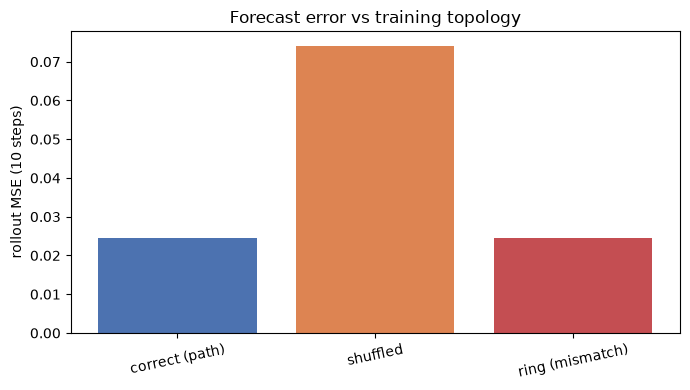

In [6]:
labels = list(rollout_errors.keys())
values = [rollout_errors[k] for k in labels]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(labels, values, color=["#4c72b0", "#dd8452", "#c44e52"])
ax.set_ylabel(f"rollout MSE ({PREDICT_STEPS} steps)")
ax.set_title("Forecast error vs training topology")
ax.tick_params(axis="x", rotation=12)
fig.tight_layout()
plt.show()

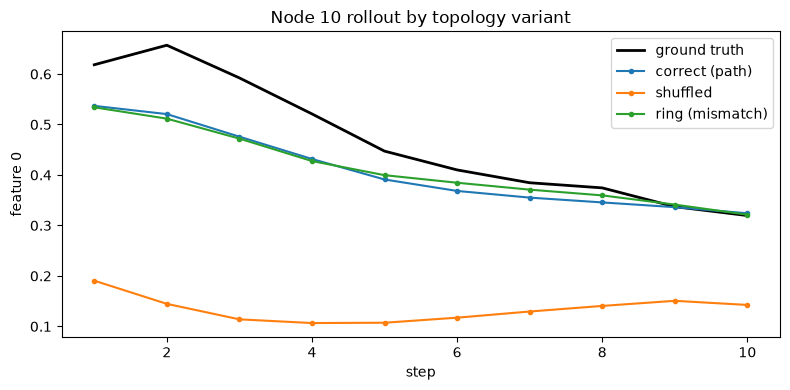

In [7]:
node_id = NUM_NODES // 2
feature_idx = 0
start = data_sequence[0]

fig, ax = plt.subplots(figsize=(8, 4))
truth = torch.stack([snap.x[node_id, feature_idx] for snap in data_sequence[1 : PREDICT_STEPS + 1]])
ax.plot(range(1, PREDICT_STEPS + 1), truth.numpy(), "k-", linewidth=2, label="ground truth")

for label, model in trained_models.items():
    edge_index = topology_variants[label]
    initial = Data(x=start.x.clone(), edge_index=edge_index)
    with torch.no_grad():
        preds = model.predict(initial, steps=PREDICT_STEPS)
    values = torch.stack([p.x[node_id, feature_idx] for p in preds])
    ax.plot(range(1, PREDICT_STEPS + 1), values.numpy(), marker="o", markersize=3, label=label)

ax.set_xlabel("step")
ax.set_ylabel(f"feature {feature_idx}")
ax.set_title(f"Node {node_id} rollout by topology variant")
ax.legend()
fig.tight_layout()
plt.show()

## Evaluate: encoder zoo on directional advection

Compare GCN / SAGE / DiffConv / Transformer encoders under the same advection
protocol. For a GAT-focused walkthrough on this benchmark, see
[`04_grid_attention.ipynb`](04_grid_attention.ipynb).


In [8]:
# Grid / epoch sizes come from the setup cell (smaller under CI).
adv_sequence = AnisotropicAdvectionGridBenchmark.generate(
    num_rows=ADV_ROWS,
    num_cols=ADV_COLS,
    num_timesteps=ADV_TIMESTEPS,
    in_channels=ADV_IN,
    seed=ADV_SEED,
)
assert adv_sequence.in_channels == ADV_IN

zoo_errors: dict[str, float] = {}
for kind in ("GCN", "SAGE", "DiffConv", "Transformer"):
    torch.manual_seed(MODEL_SEED)
    model = build_encoder_zoo_model(kind)
    model.fit(
        adv_sequence,
        epochs=ADV_EPOCHS,
        lr=LR,
        loss_weights=ADV_LOSS_WEIGHTS,
        rollout_horizon=min(5, ADV_STEPS),
        max_grad_norm=1.0,
    )
    zoo_errors[kind] = _rollout_mse_on_sequence(model, adv_sequence, ADV_STEPS)
    print(f"{kind:12s} rollout MSE = {zoo_errors[kind]:.6f}")


GCN          rollout MSE = 0.003856
SAGE         rollout MSE = 0.000184
DiffConv     rollout MSE = 0.000803
Transformer  rollout MSE = 0.001347


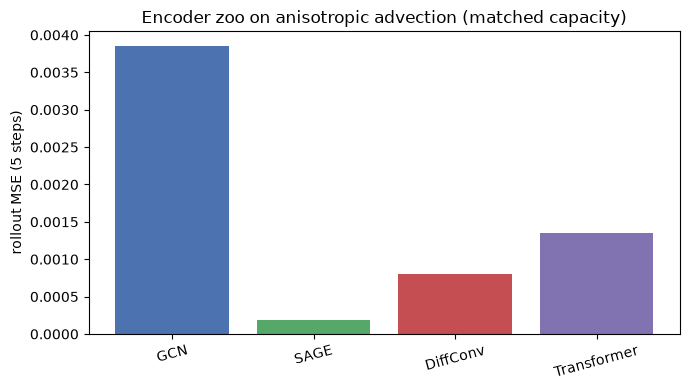

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
labels = list(zoo_errors.keys())
values = [zoo_errors[k] for k in labels]
ax.bar(
    labels,
    values,
    color=["#4c72b0", "#55a868", "#c44e52", "#8172b2"],
)
ax.set_ylabel(f"rollout MSE ({ADV_STEPS} steps)")
ax.set_title("Encoder zoo on anisotropic advection (matched capacity)")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()


## Takeaways

- **Shuffling** the edges roughly triples rollout error: message passing no longer
  reflects how information actually propagated through the graph.
- The **ring** variant performs indistinguishably from the correct path topology
  on this benchmark. It preserves all 38 true path edges and only adds the two
  wrap-around boundary edges, so local message passing is almost unchanged — the
  model degrades with how *badly* the topology is mis-specified, not merely with
  whether it is exactly correct.
- Matching **edge_index** to the true coupling in the data therefore matters most
  when the candidate topology scrambles neighborhoods, and least for small
  structural perturbations.
- On **anisotropic advection**, this notebook’s grid snapshots carry an unweighted
  lattice ``edge_index`` only — the west/north bias lives in the *dynamics
  generator*, not in attached ``edge_weight``. At matched capacity the usual
  ranking here is **SAGE ≪ DiffConv ≪ Transformer ≪ GCN** (lower MSE better):
  GraphSAGE is the strongest default peer on this unweighted setup; DiffConv’s
  diffusion inductive bias still beats plain GCN even without asymmetric weights
  (DiffConv can use ``edge_weight`` when you supply it); the Transformer peer
  adds longer-range attention at higher edges×heads cost — optional, not the
  default.
- This complements `03_traffic_network.ipynb`, which compares graph-aware KoopmanGraph to a **vectorized** baseline that ignores edges entirely.

## Next steps

- See [`04_grid_attention.ipynb`](04_grid_attention.ipynb) for GAT on directional advection.
- See [`18_networked_koopman_dynamic_topology.ipynb`](18_networked_koopman_dynamic_topology.ipynb) for topology in the linear step.
- See [`01_synthetic_graph.ipynb`](01_synthetic_graph.ipynb) for the base workflow.
- Explore the [API reference](https://koopmangraph.readthedocs.io/en/latest/api.html).
